# 05. Full Dataset Quantitative Audit

04-1에서는 method 후보를 빠르게 비교하기 위해 씬당 12장, 총 108장 샘플을 사용했다. 하지만 최종 파이프라인 결정에서 정량 지표는 전체 `01_lane_drive_capture` 데이터를 대상으로 계산하는 것이 맞다.

따라서 이 노트북은 다음 원칙으로 진행한다.

- 정량 지표: field2 lane 데이터 전체 이미지에 대해 계산함.
- 시각 검수: 전체 이미지를 모두 보여줄 수 없으므로 scene별 샘플 grid만 생성함.
- 최종 선택: 전체 정량 결과와 04-1 시각 검수 결과를 함께 보고 결정함.

중요한 점은 여기서의 정량 지표도 절대적인 ground-truth 성능이 아니라, HSV pseudo-label의 구조적 위험을 측정하는 heuristic이다. 실제 사람이 그린 lane label이 없기 때문에, 이 metric은 `정답과의 IoU`가 아니라 `pseudo-label이 학습 데이터로 써도 덜 위험한가`를 보는 용도다.


In [1]:
from __future__ import annotations

import csv
import json
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PIPELINE_ROOT = Path(r"~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/05_lane_finetune_dataset_pipeline")
sys.path.insert(0, str(PIPELINE_ROOT / "src"))

import pipeline_common as pc

pc.ensure_dirs(pc.OUTPUTS, pc.REPORTS, PIPELINE_ROOT / "configs")

with (PIPELINE_ROOT / "configs" / "field2_builder_v1_hsv.json").open("r", encoding="utf-8") as f:
    base_config = json.load(f)
with (PIPELINE_ROOT / "configs" / "field2_builder_v2_pairing_decision.json").open("r", encoding="utf-8") as f:
    decision_config = json.load(f)

HSV_CFG = base_config["hsv"]
MANIFEST_PATH = pc.MANIFESTS / "01_lane_drive_capture_manifest.csv"
print("hsv:", HSV_CFG)
print("manifest:", MANIFEST_PATH)


hsv: {'lower': [22, 90, 110], 'upper': [38, 255, 255], 'morph_kernel': 5}
manifest: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\manifests\01_lane_drive_capture_manifest.csv


## 1. 전체 데이터 로드

`01_lane_drive_capture_manifest.csv`에 기록된 raw image 중 실제 로컬에 존재하는 파일을 모두 평가 대상으로 사용한다.


In [2]:
SCENE_ORDER = [
    "straight",
    "left_curve",
    "right_curve",
    "off_center_left",
    "off_center_right",
    "intersection_approach",
    "intersection_left",
    "intersection_right",
    "failure_cases",
]
SCENE_POLICY = {
    "straight": "train_candidate",
    "left_curve": "train_candidate",
    "right_curve": "train_candidate",
    "off_center_left": "train_candidate",
    "off_center_right": "train_candidate",
    "intersection_approach": "needs_review",
    "intersection_left": "needs_review",
    "intersection_right": "needs_review",
    "failure_cases": "holdout_or_hard_case",
}

with MANIFEST_PATH.open("r", encoding="utf-8", newline="") as f:
    manifest = list(csv.DictReader(f))

rows_all = []
for row in manifest:
    local = pc.pi_path_to_local(row.get("raw_path", ""))
    if local is not None and pc.path_exists(local):
        row = dict(row)
        row["local_raw_path"] = str(local)
        row["policy"] = SCENE_POLICY.get(row.get("label", ""), "unknown")
        rows_all.append(row)

scene_counts = pd.DataFrame([
    {
        "scene": scene,
        "policy": SCENE_POLICY.get(scene, "unknown"),
        "count": sum(1 for r in rows_all if r.get("label") == scene),
    }
    for scene in SCENE_ORDER
])
display(scene_counts)
print("total images:", len(rows_all))


,scene,policy,count
0,straight,train_candidate,57
1,left_curve,train_candidate,227
2,right_curve,train_candidate,231
3,off_center_left,train_candidate,344
4,off_center_right,train_candidate,455
5,intersection_approach,needs_review,93
6,intersection_left,needs_review,285
7,intersection_right,needs_review,287
8,failure_cases,holdout_or_hard_case,488


total images: 2467


## 2. 비교할 method config

04-1에서 결정한 대표 후보를 그대로 사용한다. 특히 `component_poly`는 내부 sweep 결과를 반영한 best config를 사용한다.


In [3]:
METHOD_CONFIGS = {
    "rowwise": {"method": "rowwise", "y_step": 8, "min_run_width": 4, "min_points": 8},
    "rowwise_poly": {"method": "rowwise_poly", "y_step": 8, "min_run_width": 4, "min_points": 8, "degree": 2},
    "sliding_window_poly": {"method": "sliding_window_poly", "y_step": 8, "min_run_width": 4, "min_points": 8, "search_radius": 90.0, "smooth_alpha": 0.25, "degree": 2},
    "component_poly": dict(decision_config["pairing_component_poly_best"]),
}
print(json.dumps(METHOD_CONFIGS, indent=2, ensure_ascii=False))


{
  "rowwise": {
    "method": "rowwise",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8
  },
  "rowwise_poly": {
    "method": "rowwise_poly",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8,
    "degree": 2
  },
  "sliding_window_poly": {
    "method": "sliding_window_poly",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8,
    "search_radius": 90.0,
    "smooth_alpha": 0.25,
    "degree": 2
  },
  "component_poly": {
    "method": "component_poly",
    "y_step": 6,
    "min_run_width": 4,
    "min_points": 8,
    "min_area": 450,
    "min_height": 120,
    "degree": 2
  }
}


## 3. 정량 지표 정의

이미지마다 HSV mask를 한 번 만들고, 같은 mask에 대해 4개 method를 모두 실행한다. 이렇게 해야 method 차이만 비교할 수 있다.

주요 지표는 다음과 같다.

- `two_lane_rate`: 두 개 이상의 lane line을 만든 비율. 높으면 좋지만, 틀린 두 선을 만들 수도 있음.
- `one_or_more_rate`: 최소 한 개 lane line을 만든 비율.
- `mask_support`: 출력된 line point가 HSV mask 위에 놓인 비율.
- `duplicate_component_rate`: 두 lane이 같은 connected component에 붙은 비율. 같은 물리 차선을 두 개로 쪼갰을 위험.
- `crossing_rate`: 좌우 lane의 x 순서가 뒤집힌 비율.
- `small_gap_rate`: 두 lane 사이 간격이 너무 작아 사실상 같은 선일 가능성이 있는 비율.
- `conservative_label_score`: pseudo-label 학습용 관점에서 보수적으로 계산한 종합 점수.


In [4]:
def make_mask(path: Path):
    rgb = pc.load_rgb(path)
    crop = pc.crop_road(rgb)
    mask_crop = pc.hsv_yellow_mask(crop, lower=tuple(HSV_CFG["lower"]), upper=tuple(HSV_CFG["upper"]), morph_kernel=int(HSV_CFG["morph_kernel"]))
    return rgb, pc.crop_mask_to_raw(mask_crop)


def point_component_id(labels, x, y, radius=5):
    h, w = labels.shape
    x = int(round(x)); y = int(round(y))
    x1 = max(0, x - radius); x2 = min(w, x + radius + 1)
    y1 = max(0, y - radius); y2 = min(h, y + radius + 1)
    patch = labels[y1:y2, x1:x2]
    vals = patch[patch > 0]
    if vals.size == 0:
        return 0
    ids, counts = np.unique(vals, return_counts=True)
    return int(ids[np.argmax(counts)])


def lane_component_stats(lane, labels):
    if not lane:
        return {"support_fraction": 0.0, "dominant_component": 0, "dominant_fraction": 0.0}
    ids = [point_component_id(labels, x, y) for x, y in lane]
    nonzero = [i for i in ids if i > 0]
    support = len(nonzero) / max(1, len(ids))
    if not nonzero:
        return {"support_fraction": support, "dominant_component": 0, "dominant_fraction": 0.0}
    vals, counts = np.unique(np.array(nonzero), return_counts=True)
    idx = int(np.argmax(counts))
    return {"support_fraction": float(support), "dominant_component": int(vals[idx]), "dominant_fraction": float(counts[idx] / max(1, len(nonzero)))}


def interpolate_x(lane, ys):
    pts = pc.sort_lane_bottom_to_top(lane)
    lane_y = np.array([p[1] for p in pts], dtype=np.float32)
    lane_x = np.array([p[0] for p in pts], dtype=np.float32)
    order = np.argsort(lane_y)
    return np.interp(ys, lane_y[order], lane_x[order])


def geometry_pair_stats(lanes):
    if len(lanes) < 2:
        return {"has_pair": 0.0, "median_gap": np.nan, "min_gap": np.nan, "crossing_risk": 0.0, "small_gap_risk": 0.0}
    left, right = lanes[0], lanes[1]
    y_min = max(min(p[1] for p in left), min(p[1] for p in right), pc.GEOM.cut_height)
    y_max = min(max(p[1] for p in left), max(p[1] for p in right), pc.GEOM.raw_height - 1)
    if y_max <= y_min + 10:
        return {"has_pair": 1.0, "median_gap": np.nan, "min_gap": np.nan, "crossing_risk": 1.0, "small_gap_risk": 1.0}
    ys = np.linspace(y_min, y_max, 32)
    lx = interpolate_x(left, ys)
    rx = interpolate_x(right, ys)
    gaps = rx - lx
    return {"has_pair": 1.0, "median_gap": float(np.median(gaps)), "min_gap": float(np.min(gaps)), "crossing_risk": float(np.mean(gaps <= 15.0)), "small_gap_risk": float(np.mean(gaps < 45.0))}


def diagnostics_from_lanes(row, method_name, lanes, labels):
    lanes = sorted(lanes, key=lambda lane: np.median([p[0] for p in lane]) if lane else 1e9)
    comp_stats = [lane_component_stats(lane, labels) for lane in lanes]
    doms = [s["dominant_component"] for s in comp_stats]
    duplicate_component = 0.0
    if len(doms) >= 2 and doms[0] > 0 and doms[0] == doms[1]:
        if comp_stats[0]["dominant_fraction"] >= 0.45 and comp_stats[1]["dominant_fraction"] >= 0.45:
            duplicate_component = 1.0
    spans = [pc.lane_y_span(lane) for lane in lanes]
    smooths = [pc.lane_smoothness(lane) for lane in lanes if len(lane) >= 4]
    supports = [s["support_fraction"] for s in comp_stats]
    return {
        "scene": row["label"], "policy": row["policy"], "file": Path(row["local_raw_path"]).name, "method": method_name,
        "num_lanes": len(lanes), "two_lane": float(len(lanes) >= 2), "one_or_more": float(len(lanes) >= 1), "no_lane": float(len(lanes) == 0),
        "point_total": sum(len(lane) for lane in lanes), "median_points": float(np.median([len(lane) for lane in lanes])) if lanes else 0.0,
        "median_y_span": float(np.median(spans)) if spans else 0.0,
        "median_smoothness": float(np.median(smooths)) if smooths else np.nan,
        "mask_support": float(np.mean(supports)) if supports else 0.0,
        "duplicate_component_risk": duplicate_component,
        "dominant_components": ",".join(str(d) for d in doms),
        **geometry_pair_stats(lanes),
    }


def run_all_methods_for_row(row):
    rgb, mask_raw = make_mask(Path(row["local_raw_path"]))
    _, labels, _, _ = cv2.connectedComponentsWithStats((mask_raw > 0).astype(np.uint8), 8)
    records = []
    for method_name, cfg in METHOD_CONFIGS.items():
        method = cfg["method"]
        params = {k: v for k, v in cfg.items() if k != "method"}
        lanes, _ = pc.extract_lanes_by_method(mask_raw, method=method, **params)
        records.append(diagnostics_from_lanes(row, method_name, lanes, labels))
    return records


## 4. 전체 데이터 정량 평가 실행

2467장 전체에 대해 실행한다. 이미지는 한 번만 읽고, 같은 HSV mask에 4가지 method를 적용한다.


In [5]:
records = []
for idx, row in enumerate(rows_all, start=1):
    if idx == 1 or idx % 250 == 0 or idx == len(rows_all):
        print(f"processing {idx}/{len(rows_all)}: {row['label']} {row['frame_id']}")
    records.extend(run_all_methods_for_row(row))

full_diag_df = pd.DataFrame(records)
raw_csv = pc.REPORTS / "05_full_method_raw_diagnostics.csv"
full_diag_df.to_csv(raw_csv, index=False, encoding="utf-8-sig")
print(raw_csv)
print(full_diag_df.shape)


processing 1/2467: straight 00149


processing 250/2467: left_curve 00367


processing 500/2467: right_curve 00254


processing 750/2467: intersection_left 00973


processing 1000/2467: intersection_right 00808


...

processing 1500/2467: off_center_right 01202


processing 1750/2467: off_center_right 01113


processing 2000/2467: failure_cases 00200


processing 2250/2467: failure_cases 00560


processing 2467/2467: failure_cases 02068
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\05_full_method_raw_diagnostics.csv
(9868, 20)


## 5. 전체 / 정책별 / 씬별 요약

전체 평균만 보면 `failure_cases`나 교차로처럼 실제 학습 투입 전 검토가 필요한 구간이 섞인다. 따라서 전체, `train_candidate`, `needs_review`, `holdout_or_hard_case`를 나누어 본다.


In [6]:
def safe_mean(series):
    return float(pd.to_numeric(series, errors="coerce").mean())


def summarize_group(df, group_name, group_value):
    out = []
    for method_name, g in df.groupby("method", sort=False):
        scene_rates = [safe_mean(sg["one_or_more"]) for _, sg in g.groupby("scene")]
        two_lane_rate = safe_mean(g["two_lane"])
        one_or_more_rate = safe_mean(g["one_or_more"])
        no_lane_rate = safe_mean(g["no_lane"])
        span_norm = float(np.nanmedian(g["median_y_span"]) / pc.GEOM.visible_height)
        points_norm = float(min(1.0, np.nanmedian(g["median_points"]) / 80.0))
        smooth_median = float(np.nanmedian(g["median_smoothness"]))
        smooth_penalty = float(min(1.0, smooth_median / 12.0)) if not np.isnan(smooth_median) else 1.0
        mask_support = safe_mean(g["mask_support"])
        duplicate_component_rate = safe_mean(g["duplicate_component_risk"])
        crossing_rate = safe_mean(g["crossing_risk"])
        small_gap_rate = safe_mean(g["small_gap_risk"])
        scene_balance = float(min(scene_rates)) if scene_rates else 0.0
        coverage_score = 60 * two_lane_rate + 20 * one_or_more_rate + 15 * span_norm + 5 * points_norm - 50 * no_lane_rate
        consistency_score = 35 * mask_support + 35 * (1.0 - duplicate_component_rate) + 20 * (1.0 - crossing_rate) + 10 * (1.0 - small_gap_rate)
        conservative_label_score = 30 * one_or_more_rate + 20 * two_lane_rate + 15 * span_norm + 15 * mask_support + 10 * scene_balance - 35 * duplicate_component_rate - 25 * crossing_rate - 15 * small_gap_rate - 10 * smooth_penalty
        out.append({
            group_name: group_value, "method": method_name, "samples": int(len(g)), "two_lane_rate": two_lane_rate,
            "one_or_more_rate": one_or_more_rate, "no_lane_rate": no_lane_rate, "scene_balance": scene_balance,
            "median_y_span": float(np.nanmedian(g["median_y_span"])), "median_points": float(np.nanmedian(g["median_points"])),
            "median_smoothness": smooth_median, "mask_support": mask_support,
            "duplicate_component_rate": duplicate_component_rate, "crossing_rate": crossing_rate, "small_gap_rate": small_gap_rate,
            "coverage_score": coverage_score, "consistency_score": consistency_score, "conservative_label_score": conservative_label_score,
        })
    return out

summary_rows = []
summary_rows.extend(summarize_group(full_diag_df, "group", "all"))
for policy, g in full_diag_df.groupby("policy"):
    summary_rows.extend(summarize_group(g, "group", policy))
full_summary_df = pd.DataFrame(summary_rows).sort_values(["group", "conservative_label_score"], ascending=[True, False])

display(full_summary_df)
full_summary_df.to_csv(pc.REPORTS / "05_full_method_summary_by_group.csv", index=False, encoding="utf-8-sig")


,group,method,samples,two_lane_rate,one_or_more_rate,no_lane_rate,scene_balance,median_y_span,median_points,median_smoothness,mask_support,duplicate_component_rate,crossing_rate,small_gap_rate,coverage_score,consistency_score,conservative_label_score
3,all,component_poly,2467,0.640454,0.971220,0.028780,0.854508,321.0,54.50,0.275811,0.888727,0.000000,0.045640,0.045767,68.955519,94.734990,70.900956
2,all,sliding_window_poly,2467,0.807864,0.986218,0.013782,0.930328,372.0,47.00,0.312501,0.651279,0.231861,0.109179,0.122809,81.032829,76.267988,62.457386
1,all,rowwise_poly,2467,0.873936,0.986218,0.013782,0.930328,356.0,45.50,0.520375,0.654382,0.292258,0.082755,0.084921,84.448000,75.170051,62.311748
0,all,rowwise,2467,0.873936,0.986218,0.013782,0.930328,364.0,40.50,24.308101,0.986218,0.246048,0.083895,0.091622,84.363204,88.311841,59.438967
5,holdout_or_hard_case,rowwise_poly,488,0.657787,0.930328,0.069672,0.930328,256.0,32.50,0.685718,0.636589,0.329918,0.087282,0.087987,63.907941,73.107956,51.583789
7,holdout_or_hard_case,component_poly,488,0.196721,0.854508,0.145492,0.854508,222.0,38.00,0.359127,0.758386,0.000000,0.106557,0.106557,30.312638,88.346781,51.247759
6,holdout_or_hard_case,sliding_window_poly,488,0.606557,0.930328,0.069672,0.930328,268.0,34.25,0.604638,0.603181,0.319672,0.094390,0.109567,61.285102,71.939337,50.324408
4,holdout_or_hard_case,rowwise,488,0.657787,0.930328,0.069672,0.930328,268.0,28.00,42.997446,0.930328,0.233607,0.087346,0.091701,63.968247,86.721311,50.216454
11,needs_review,component_poly,665,0.890226,1.000000,0.000000,1.000000,315.0,53.50,0.421886,0.869811,0.000000,0.074577,0.075047,85.723128,93.201387,76.475823
10,needs_review,sliding_window_poly,665,0.935338,1.000000,0.000000,1.000000,412.0,52.00,0.357345,0.563560,0.150376,0.045442,0.051034,91.097056,78.042253,71.424419


In [7]:
scene_summary_rows = []
for (scene, method), g in full_diag_df.groupby(["scene", "method"]):
    scene_summary_rows.append({
        "scene": scene,
        "policy": SCENE_POLICY.get(scene, "unknown"),
        "method": method,
        "samples": int(len(g)),
        "two_lane_rate": safe_mean(g["two_lane"]),
        "one_or_more_rate": safe_mean(g["one_or_more"]),
        "mask_support": safe_mean(g["mask_support"]),
        "duplicate_component_rate": safe_mean(g["duplicate_component_risk"]),
        "crossing_rate": safe_mean(g["crossing_risk"]),
        "small_gap_rate": safe_mean(g["small_gap_risk"]),
        "median_y_span": float(np.nanmedian(g["median_y_span"])),
        "median_smoothness": float(np.nanmedian(g["median_smoothness"])),
    })
scene_method_df = pd.DataFrame(scene_summary_rows)
scene_method_df.to_csv(pc.REPORTS / "05_full_method_summary_by_scene.csv", index=False, encoding="utf-8-sig")

display(scene_method_df.pivot(index="scene", columns="method", values="duplicate_component_rate").loc[SCENE_ORDER])
display(scene_method_df.pivot(index="scene", columns="method", values="crossing_rate").loc[SCENE_ORDER])


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,0.0,0.000000,0.000000,0.000000
left_curve,0.0,0.422907,0.466960,0.383260
right_curve,0.0,0.441558,0.476190,0.454545
off_center_left,0.0,0.145349,0.183140,0.151163
off_center_right,0.0,0.210989,0.206593,0.158242
intersection_approach,0.0,0.000000,0.000000,0.000000
intersection_left,0.0,0.252632,0.326316,0.171930
intersection_right,0.0,0.268293,0.327526,0.177700
failure_cases,0.0,0.233607,0.329918,0.319672


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,0.000000,0.000000,0.000000,0.000000
left_curve,0.000000,0.299559,0.299559,0.272715
right_curve,0.000000,0.203463,0.204816,0.263799
off_center_left,0.008721,0.068405,0.060865,0.074400
off_center_right,0.017582,0.054396,0.054121,0.098077
intersection_approach,0.010753,0.000000,0.000000,0.000000
intersection_left,0.101864,0.001316,0.000768,0.018531
intersection_right,0.068162,0.002395,0.001633,0.086890
failure_cases,0.106557,0.087346,0.087282,0.094390


## 6. 시각 검수 pack

정량 평가는 전체 데이터로 수행했지만, 이미지를 전부 펼쳐 볼 수는 없다. 대신 scene별 대표 샘플을 골라 시각 검수 pack을 저장한다.


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\outputs\05_full_method_visual_grid.png


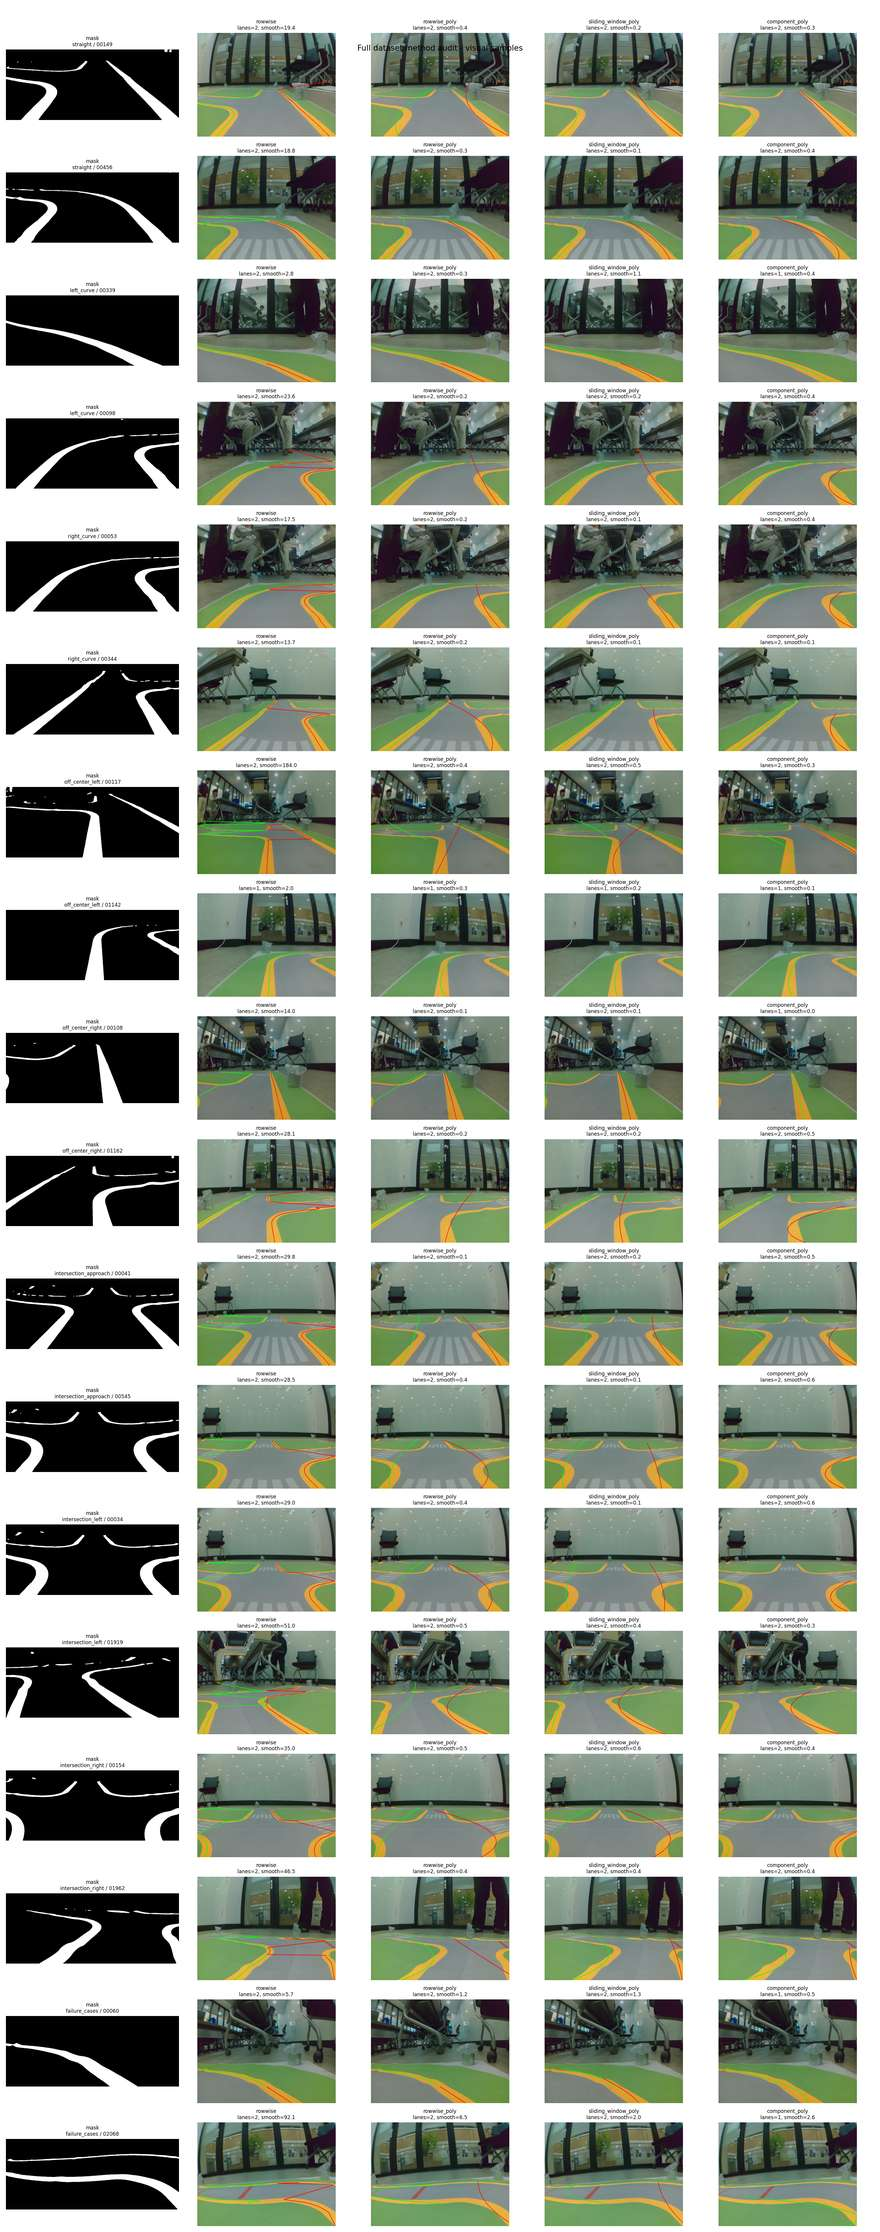

In [8]:
def make_mask_for_visual(row):
    return make_mask(Path(row["local_raw_path"]))


def run_method_for_visual(mask_raw, cfg):
    method = cfg["method"]
    params = {k: v for k, v in cfg.items() if k != "method"}
    lanes, q = pc.extract_lanes_by_method(mask_raw, method=method, **params)
    lanes = sorted(lanes, key=lambda lane: np.median([p[0] for p in lane]) if lane else 1e9)
    return lanes, q


def make_grid(rows, out_path: Path, title: str):
    cols = ["mask"] + list(METHOD_CONFIGS.keys())
    fig, axes = plt.subplots(len(rows), len(cols), figsize=(4.4 * len(cols), 3.1 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)
    for r_idx, row in enumerate(rows):
        rgb, mask_raw = make_mask_for_visual(row)
        axes[r_idx, 0].imshow(mask_raw[pc.GEOM.cut_height:, :], cmap="gray")
        axes[r_idx, 0].set_title(f"mask\n{row['label']} / {row['frame_id']}", fontsize=9)
        axes[r_idx, 0].axis("off")
        for c_idx, (method_name, cfg) in enumerate(METHOD_CONFIGS.items(), start=1):
            lanes, q = run_method_for_visual(mask_raw, cfg)
            overlay = pc.overlay_lanes(rgb, lanes, mask_raw)
            axes[r_idx, c_idx].imshow(overlay)
            axes[r_idx, c_idx].set_title(f"{method_name}\nlanes={len(lanes)}, smooth={q.get('median_smoothness', np.nan):.1f}", fontsize=9)
            axes[r_idx, c_idx].axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    fig.savefig(pc.windows_long_path(out_path), dpi=135)
    plt.close(fig)
    return out_path

by_scene = defaultdict(list)
for row in rows_all:
    by_scene[row["label"]].append(row)

visual_rows = []
for scene in SCENE_ORDER:
    visual_rows.extend(pc.pick_evenly(by_scene[scene], 2))
visual_grid = make_grid(visual_rows, pc.OUTPUTS / "05_full_method_visual_grid.png", "Full dataset method audit - visual samples")
print(visual_grid)
display(Image(filename=str(visual_grid)))


## 7. 전체 정량 기반 decision config 저장

기존 `field2_builder_v2_pairing.json`은 아직 덮어쓰지 않는다. 전체 데이터 정량 결과를 별도 decision config로 저장한 뒤, 사람이 시각 grid를 확인하고 승격한다.


In [9]:
all_summary = full_summary_df[full_summary_df["group"] == "all"].sort_values("conservative_label_score", ascending=False)
train_summary = full_summary_df[full_summary_df["group"] == "train_candidate"].sort_values("conservative_label_score", ascending=False)
selected_all = str(all_summary.iloc[0]["method"])
selected_train = str(train_summary.iloc[0]["method"])
selected_method = selected_train
selected_pairing = dict(METHOD_CONFIGS[selected_method])

full_decision = dict(base_config)
full_decision["name"] = "field2_builder_v2_full_dataset_method_decision"
full_decision["pairing_method_candidates"] = METHOD_CONFIGS
full_decision["pairing"] = selected_pairing
full_decision["method_decision"] = {
    "selected_by_all_images": selected_all,
    "selected_by_train_candidate_images": selected_train,
    "selected_pairing": selected_pairing,
    "metric_scope": "all field2 lane_drive_capture images",
    "total_images": len(rows_all),
    "note": "Quantitative metrics use all images; visual grid is sampled. Inspect before overwriting field2_builder_v2_pairing.json.",
}

report = {
    "selected_by_all_images": selected_all,
    "selected_by_train_candidate_images": selected_train,
    "selected_pairing": selected_pairing,
    "total_images": len(rows_all),
    "summary_by_group": full_summary_df.to_dict(orient="records"),
    "summary_by_scene": scene_method_df.to_dict(orient="records"),
    "visual_output": str(visual_grid),
    "raw_diagnostics_csv": str(raw_csv),
}
config_path = PIPELINE_ROOT / "configs" / "30_pipelines/culane_pseudo_dataset_builder/configs/project_map_field2_component_poly.json"
report_path = pc.REPORTS / "05_full_method_decision_report.json"
pc.write_json(config_path, full_decision)
pc.write_json(report_path, report)
print("selected by all images:", selected_all)
print("selected by train candidate:", selected_train)
print("selected pairing:", selected_pairing)
print("config:", config_path)
print("report:", report_path)


selected by all images: component_poly
selected by train candidate: component_poly
selected pairing: {'method': 'component_poly', 'y_step': 6, 'min_run_width': 4, 'min_points': 8, 'min_area': 450, 'min_height': 120, 'degree': 2}
config: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\configs\30_pipelines/culane_pseudo_dataset_builder/configs/project_map_field2_component_poly.json
report: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\05_full_method_decision_report.json


## 8. 결과 메모

사용자 지적대로, 최종 method 결정을 위한 정량 지표는 샘플이 아니라 전체 field2 lane 데이터에 대해 계산했다. 총 2467장의 `01_lane_drive_capture` 이미지에 대해 동일한 HSV mask를 만들고, 그 mask에 네 가지 method를 모두 적용했다.

전체 이미지 기준 결과는 아래와 같다.

| method | two-lane rate | one+ rate | mask support | duplicate risk | crossing risk | conservative score |
|---|---:|---:|---:|---:|---:|---:|
| component_poly | 0.640 | 0.971 | 0.889 | 0.000 | 0.046 | 70.90 |
| rowwise_poly | 0.874 | 0.986 | 0.654 | 0.292 | 0.083 | 62.31 |
| sliding_window_poly | 0.808 | 0.986 | 0.651 | 0.232 | 0.109 | 62.46 |
| rowwise | 0.874 | 0.986 | 0.986 | 0.246 | 0.084 | 59.44 |

학습 후보 구간(`straight`, `curve`, `off-center`)만 따로 보면 다음과 같다.

| method | two-lane rate | mask support | duplicate risk | crossing risk | conservative score |
|---|---:|---:|---:|---:|---:|
| component_poly | 0.679 | 0.947 | 0.000 | 0.008 | 76.72 |
| rowwise_poly | 0.890 | 0.731 | 0.284 | 0.122 | 63.79 |
| sliding_window_poly | 0.818 | 0.714 | 0.240 | 0.147 | 63.02 |
| rowwise | 0.890 | 1.000 | 0.262 | 0.124 | 58.95 |

결론은 04-1 샘플 실험과 동일하다. 전체 데이터 기준으로도 `component_poly`가 가장 안전한 pseudo-label method다.

이유는 명확하다.

- `rowwise_poly`는 전체 two-lane rate가 0.874로 높지만 duplicate risk가 0.292이다. 같은 물리 노란선을 두 개 lane으로 쪼개는 문제가 많다.
- `sliding_window_poly`도 two-lane rate는 0.808로 높지만 duplicate risk가 0.232이고 mask support도 0.651로 낮다.
- `component_poly`는 two-lane rate가 0.640로 낮다. 대신 duplicate risk가 0.000이고, mask support가 0.889로 가장 안정적이다. pseudo-label에서는 틀린 두 선보다 맞는 한 선이 낫다.

따라서 전체 데이터 정량 기준과 시각 검수 기준을 합치면 추천 method는 `component_poly`이다. 추천 파라미터는 `{"method": "component_poly", "y_step": 6, "min_run_width": 4, "min_points": 8, "min_area": 450, "min_height": 120, "degree": 2}`이다.

저장된 산출물은 다음과 같다.

- `notebooks/05_lane_extraction_method_full_audit.ipynb`
- `reports/05_full_method_decision_report.json`
- `reports/05_full_method_summary_by_group.csv`
- `reports/05_full_method_summary_by_scene.csv`
- `reports/05_full_method_raw_diagnostics.csv`
- `configs/30_pipelines/culane_pseudo_dataset_builder/configs/project_map_field2_component_poly.json`
- `outputs/05_full_method_visual_grid.png`

이제 다음 단계에서는 `30_pipelines/culane_pseudo_dataset_builder/configs/project_map_field2_component_poly.json`을 기준으로 `06_status_rule_quality_gate_sweep.ipynb`에서 status rule을 확정한 뒤, `07_reusable_builder_preview_validation.ipynb` 이후의 dataset preview/build 단계를 실행하는 것이 맞다.
